In [5]:
import pandas as pd
import ast
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# load behaviour detection data
# =============================================================================

df1 = pd.read_csv(
    "/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/behaviour_detection.csv"
)
df1["condition"] = "grouped"

df2 = pd.read_csv(
    "/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/behaviour_detection.csv"
)
df2["condition"] = "isolated"

df3 = pd.read_csv(
    "/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/grouped+isolated/behaviour_detection.csv"
)
df3["condition"] = "grouped+isolated"

behaviour_df = pd.concat([df1, df2, df3], ignore_index=True)

# Make sure file names match the interaction video_id format
behaviour_df["file"] = behaviour_df["file"].astype(str)
behaviour_df["track_id"] = behaviour_df["track_id"].astype(int)
behaviour_df["frame"] = behaviour_df["frame"].astype(int)


# =============================================================================
# load interactions and cluster assignments
# =============================================================================

interactions = pd.read_csv(
    "/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/cropped_interactions.csv"
)

cluster = pd.read_csv(
    "/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/F15_KMAX3_DMAX4_NMIN1500--/pca-data3-F15-mcmodels4-Kmax3-Dmax4-Nmin1500-05-2026.csv"
)

# Remove .mp4 so interaction file names match behaviour_detection file names
interactions["video_id"] = interactions["file"].str.replace(".mp4", "", regex=False)


# =============================================================================
# merge cluster ID onto interactions
# =============================================================================

interactions = interactions.merge(
    cluster[["interaction_id", "Yhat.idt.pca"]],
    on="interaction_id",
    how="inner"
)


# =============================================================================
# split interaction pairs into one row per larva
# =============================================================================

keep_cols = [
    "file",
    "video_id",
    "Frame",
    "Interaction Number",
    "Normalized Frame",
    "Interaction Pair",
    "interaction_id",
    "Yhat.idt.pca"
]

# Convert "(0, 1)" strings into real tuples
interactions["Interaction Pair"] = interactions["Interaction Pair"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

interaction_tracks = (
    interactions[keep_cols]
    .assign(track_id=interactions["Interaction Pair"])
    .explode("track_id")
    .drop(columns="Interaction Pair")
    .reset_index(drop=True)
)

interaction_tracks["track_id"] = interaction_tracks["track_id"].astype(int)
interaction_tracks["frame"] = interaction_tracks["Frame"].astype(int)
interaction_tracks["file"] = interaction_tracks["video_id"].astype(str)


# =============================================================================
# merge behaviour onto each interaction-track-frame row
# =============================================================================

interaction_tracks = interaction_tracks.merge(
    behaviour_df[
        [
            "file",
            "track_id",
            "frame",
            "condition",
            "behaviour",
            "behavioural_states",
            "digging_status",
            "head_distance",
            "closest_node_node_distance",
            "closest_node_node_other_id"
        ]
    ],
    on=["file", "track_id", "frame"],
    how="left"
)

# Optional check
print(interaction_tracks.head())
print(interaction_tracks["behaviour"].isna().mean())

                       file                  video_id  Frame  \
0  2026-02-17_11-29-18_td11  2026-02-17_11-29-18_td11     52   
1  2026-02-17_11-29-18_td11  2026-02-17_11-29-18_td11     52   
2  2026-02-17_11-29-18_td11  2026-02-17_11-29-18_td11     53   
3  2026-02-17_11-29-18_td11  2026-02-17_11-29-18_td11     53   
4  2026-02-17_11-29-18_td11  2026-02-17_11-29-18_td11     54   

   Interaction Number  Normalized Frame interaction_id  Yhat.idt.pca  \
0                  10               -10          GS_10             2   
1                  10               -10          GS_10             2   
2                  10                -9          GS_10             2   
3                  10                -9          GS_10             2   
4                  10                -8          GS_10             2   

   track_id  frame         condition    behaviour behavioural_states  \
0         0     52  grouped+isolated  forward_run        forward_run   
1         2     52  grouped+isolated  

/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_80984/809382310.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


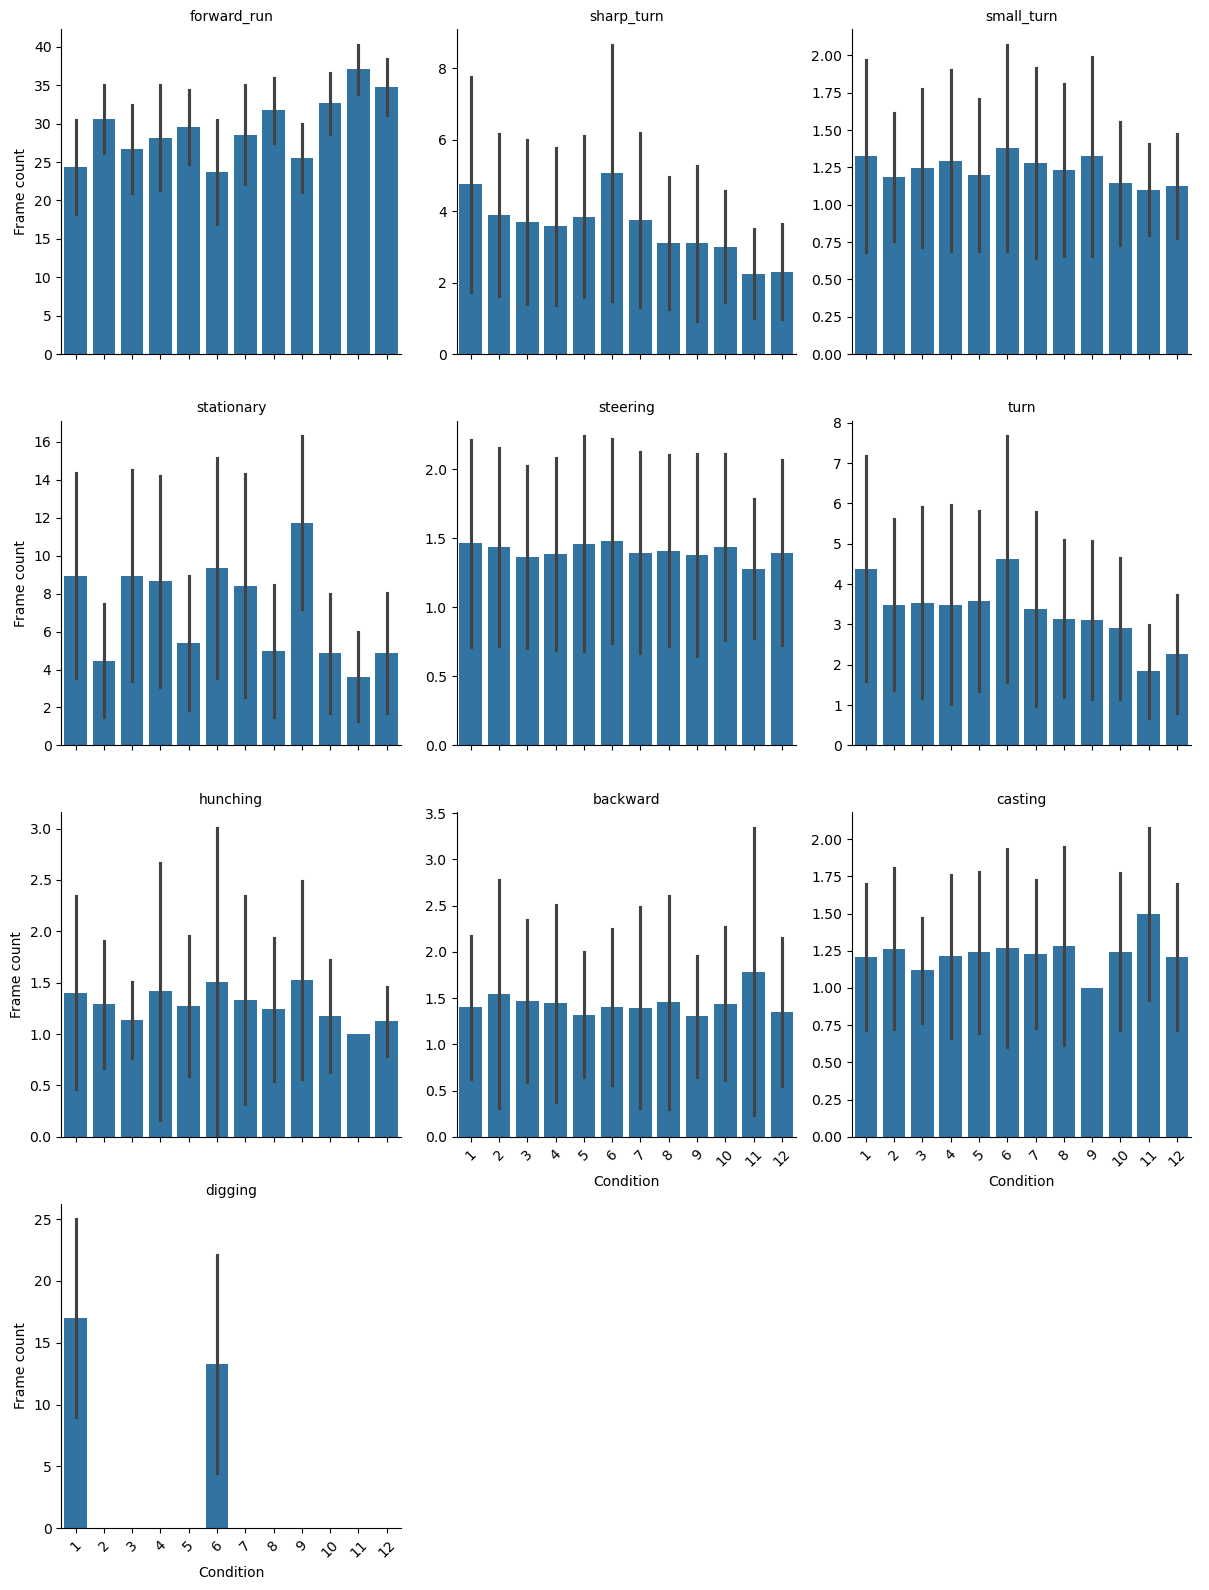

In [13]:

frequency = (
    interaction_tracks
    .dropna(subset=["condition", "file", "Yhat.idt.pca", 'interaction_id', "behaviour"])
    .groupby(["condition", "file", "Yhat.idt.pca", 'interaction_id', "behaviour"])
    .size()
    .reset_index(name="count")
)

g = sns.catplot(
    data=frequency,
    x="Yhat.idt.pca",
    y="count",
    col="behaviour",
    kind="bar",
    errorbar="sd",
    col_wrap=3,
    height=4,
    aspect=1,
    sharey=False
)

g.set_axis_labels("Condition", "Frame count")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
